# ROGII Wellbore Geology Prediction

## Notebook 02 – Exploratory Data Analysis (EDA) of a Selected Well Pair

### Objectives

- Understand the Prediction Start boundary for one illustrative well pair.
- Analyse TVT behaviour before and after Prediction Start.
- Investigate horizontal-well trajectory and GR measurements.
- Compare the selected horizontal well with its paired typewell.
- Separate intentional `TVT_input` missingness from ordinary missing data.
- Identify possible data-leakage risks and linear associations for this pair.
- Prepare evidence for feature engineering and grouped validation; corpus-wide
  missingness and well selection are continued in Notebook 03.


### 1. Import Libraries

In [30]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})
sns.set_theme(style="whitegrid", context="notebook")


### 2. Configure Project Paths

In [31]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_DIR = RAW_DIR / "train"

RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_02"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Train directory exists:", TRAIN_DIR.exists())
print("Results directory:", RESULTS_DIR.resolve())


Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Train directory exists: True
Results directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_02


### 3. Discover and validate training pairs

Well IDs are extracted by removing the exact suffixes `__typewell.csv` and
`__horizontal_well.csv`, avoiding trailing underscores left by naive replace.


In [32]:
TYPEWELL_SUFFIX = "__typewell.csv"
HORIZONTAL_SUFFIX = "__horizontal_well.csv"


def extract_well_id(filename: str, suffix: str):
    if filename.endswith(suffix):
        well_id = filename[: -len(suffix)]
        if well_id and not well_id.endswith("_"):
            return well_id
    return None


typewell_files = sorted(TRAIN_DIR.glob("*_typewell.csv"))
horizontal_files = sorted(TRAIN_DIR.glob("*_horizontal_well.csv"))

typewell_map = {}
horizontal_map = {}
malformed_typewell = []
malformed_horizontal = []

for file in typewell_files:
    well_id = extract_well_id(file.name, TYPEWELL_SUFFIX)
    if well_id is None:
        malformed_typewell.append(file.name)
    else:
        typewell_map[well_id] = file

for file in horizontal_files:
    well_id = extract_well_id(file.name, HORIZONTAL_SUFFIX)
    if well_id is None:
        malformed_horizontal.append(file.name)
    else:
        horizontal_map[well_id] = file

typewell_ids = set(typewell_map)
horizontal_ids = set(horizontal_map)

complete_ids = sorted(typewell_ids & horizontal_ids)
missing_horizontal_ids = sorted(typewell_ids - horizontal_ids)
missing_typewell_ids = sorted(horizontal_ids - typewell_ids)

well_id_validation = pd.DataFrame(
    [
        {"Metric": "Number of horizontal wells", "Count": len(horizontal_ids)},
        {"Metric": "Number of typewells", "Count": len(typewell_ids)},
        {"Metric": "Number of matched pairs", "Count": len(complete_ids)},
        {
            "Metric": "Number of unmatched files",
            "Count": (
                len(missing_horizontal_ids)
                + len(missing_typewell_ids)
                + len(malformed_typewell)
                + len(malformed_horizontal)
            ),
        },
        {
            "Metric": "Number of malformed IDs",
            "Count": len(malformed_typewell) + len(malformed_horizontal),
        },
    ]
)

display(well_id_validation)
well_id_validation.to_csv(TABLES_DIR / "well_id_validation.csv", index=False)

print("Example matched IDs:", complete_ids[:5])
assert all(not well_id.endswith("_") for well_id in complete_ids)


,Metric,Count
0,Number of horizontal wells,773
1,Number of typewells,773
2,Number of matched pairs,773
3,Number of unmatched files,0
4,Number of malformed IDs,0


Example matched IDs: ['000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4']


### 4. Load an illustrative well pair

The first lexicographically sorted matched ID is used as a worked example for
single-pair plots. It is **not** statistically representative. Notebook 03
selects typical, long-horizon, and data-quality-challenge wells using explicit
corpus-wide criteria.


In [33]:
sample_id = complete_ids[0]

typewell_path = typewell_map[sample_id]
horizontal_path = horizontal_map[sample_id]

typewell = pd.read_csv(typewell_path)
horizontal = pd.read_csv(horizontal_path)

print("Illustrative well ID:", sample_id)
print("Typewell file:", typewell_path.name)
print("Horizontal file:", horizontal_path.name)
print("Typewell shape:", typewell.shape)
print("Horizontal shape:", horizontal.shape)
assert not sample_id.endswith("_")


Illustrative well ID: 000d7d20
Typewell file: 000d7d20__typewell.csv
Horizontal file: 000d7d20__horizontal_well.csv
Typewell shape: (1296, 3)
Horizontal shape: (5278, 13)


In [34]:
print("Paired filenames for the illustrative well:")
print(" ", typewell_path.name)
print(" ", horizontal_path.name)


Paired filenames for the illustrative well:
  000d7d20__typewell.csv
  000d7d20__horizontal_well.csv


### 5. Basic dataset overview

In [35]:
overview = pd.DataFrame({
    "Dataset": ["Typewell", "Horizontal Well"],
    "Rows": [len(typewell), len(horizontal)],
    "Columns": [typewell.shape[1], horizontal.shape[1]],
    "Duplicate Rows": [
        typewell.duplicated().sum(),
        horizontal.duplicated().sum()
    ]
})

display(overview)

print("Typewell columns:")
print(typewell.columns.tolist())

print("\nHorizontal columns:")
print(horizontal.columns.tolist())

,Dataset,Rows,Columns,Duplicate Rows
0,Typewell,1296,3,0
1,Horizontal Well,5278,13,0


Typewell columns:
['TVT', 'GR', 'Geology']

Horizontal columns:
['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']


### 6. Identify the Prediction Start boundary

`TVT_input` contains the known part of the target `TVT`. After Prediction Start
it is intentionally missing in the region that must be predicted. Exact equality
between `TVT_input` and `TVT` on known rows is expected and is not an independent
predictive discovery. Conventional mean or median imputation of `TVT_input`
would erase the prediction mask and must not be used.


In [36]:
known_tvt_mask = horizontal["TVT_input"].notna()
prediction_mask = ~known_tvt_mask

known_rows = int(known_tvt_mask.sum())
prediction_rows = int(prediction_mask.sum())

missing_positions = np.where(prediction_mask.to_numpy())[0]

if len(missing_positions) > 0:
    prediction_start_position = int(missing_positions[0])
    prediction_start_md = float(horizontal.iloc[prediction_start_position]["MD"])
    last_known_position = prediction_start_position - 1
    last_known_tvt = (
        float(horizontal.iloc[last_known_position]["TVT_input"])
        if last_known_position >= 0
        else np.nan
    )
    last_known_md = (
        float(horizontal.iloc[last_known_position]["MD"])
        if last_known_position >= 0
        else np.nan
    )
else:
    prediction_start_position = None
    prediction_start_md = None
    last_known_position = len(horizontal) - 1
    last_known_tvt = float(horizontal.iloc[-1]["TVT_input"])
    last_known_md = float(horizontal.iloc[-1]["MD"])

tvt_input_matches_target = bool(
    np.allclose(
        horizontal.loc[known_tvt_mask, "TVT_input"],
        horizontal.loc[known_tvt_mask, "TVT"],
    )
)

clean_prediction_boundary = False
unexpected_internal_gaps = False
if prediction_start_position is not None:
    clean_prediction_boundary = bool(
        known_tvt_mask.iloc[:prediction_start_position].all()
        and prediction_mask.iloc[prediction_start_position:].all()
    )
    unexpected_internal_gaps = not clean_prediction_boundary
elif known_rows == len(horizontal):
    clean_prediction_boundary = True

prediction_horizon_md = (
    float(horizontal["MD"].iloc[-1] - prediction_start_md)
    if prediction_start_md is not None
    else 0.0
)

print("Known TVT rows:", known_rows)
print("Prediction rows:", prediction_rows)
print("Prediction percentage:", round(100 * prediction_rows / len(horizontal), 2))
print("Prediction start MD:", prediction_start_md)
print("Last known TVT_input:", last_known_tvt)
print("Prediction horizon (MD):", round(prediction_horizon_md, 2))
print("Clean trailing missing block:", clean_prediction_boundary)
print("Unexpected internal TVT_input gaps:", unexpected_internal_gaps)
print("TVT_input matches TVT in known section:", tvt_input_matches_target)


Known TVT rows: 1442
Prediction rows: 3836
Prediction percentage: 72.68
Prediction start MD: 12909.0
Last known TVT_input: 11747.37
Prediction horizon (MD): 3835.0
Clean trailing missing block: True
Unexpected internal TVT_input gaps: False
TVT_input matches TVT in known section: True


### 7. Visualize the Prediction Start

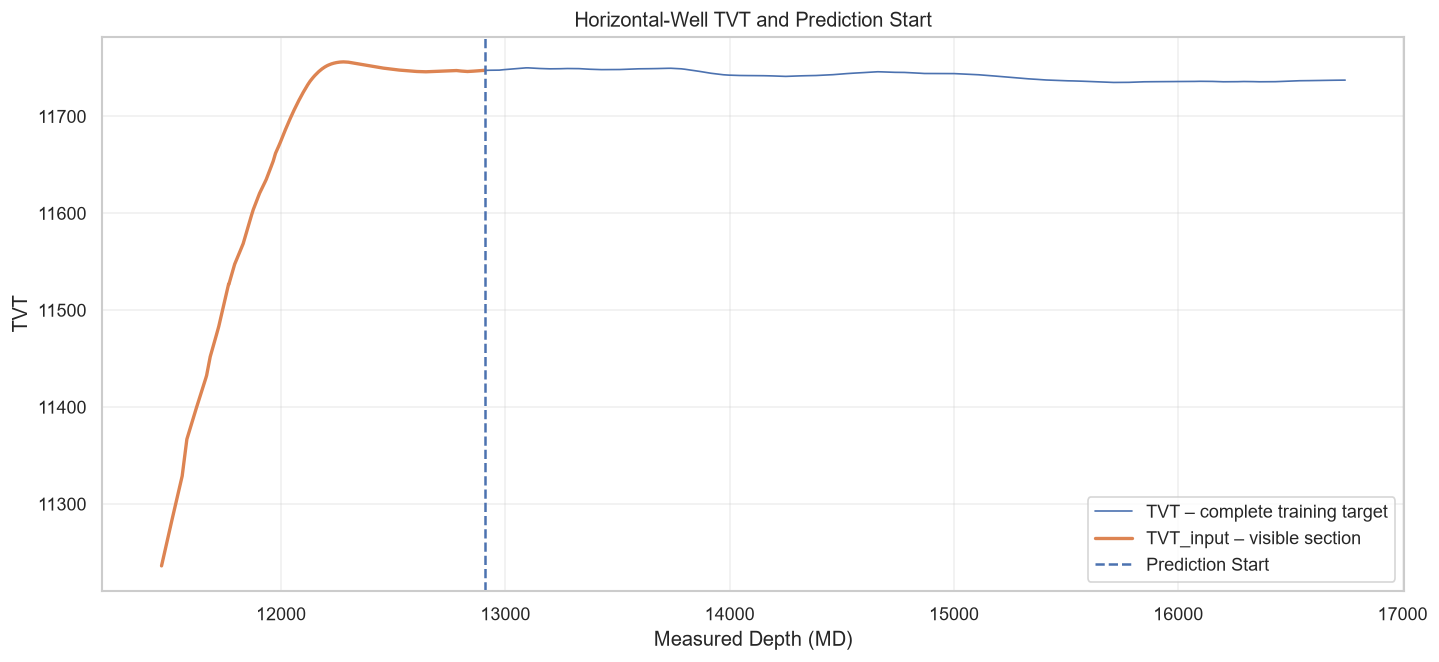

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    horizontal["MD"],
    horizontal["TVT"],
    linewidth=1,
    label="TVT – complete training target"
)

plt.plot(
    horizontal["MD"],
    horizontal["TVT_input"],
    linewidth=2,
    label="TVT_input – visible section"
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Horizontal-Well TVT and Prediction Start")
plt.xlabel("Measured Depth (MD)")
plt.ylabel("TVT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation.** The figure contrasts complete training `TVT` with visible
`TVT_input` and marks Prediction Start. The important finding is the long
trailing region without `TVT_input`. This defines the supervised prediction
horizon for this well. The limitation is single-well scope. The implication is
that baselines using the last known TVT may work when the remaining TVT change
is small, which Notebook 03 tests across wells.


### 8. Missing-value analysis

Report ordinary missingness (`GR`, typewell `Geology`) separately from
intentional `TVT_input` missingness. Do not interpret `TVT_input` NaNs as
candidates for conventional imputation.


In [38]:
def missing_summary(dataframe):
    missing_count = dataframe.isna().sum()
    missing_percent = missing_count / len(dataframe) * 100

    return pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage": missing_percent.round(2)
    }).sort_values("Missing Count", ascending=False)


print("Typewell missing values")
display(missing_summary(typewell))

print("Horizontal-well missing values")
display(missing_summary(horizontal))

Typewell missing values


,Missing Count,Missing Percentage
Geology,299,23.0700
TVT,0,0.0000
GR,0,0.0000


Horizontal-well missing values


,Missing Count,Missing Percentage
TVT_input,3836,72.6800
GR,2258,42.7800
Y,0,0.0000
X,0,0.0000
MD,0,0.0000
ANCC,0,0.0000
Z,0,0.0000
ASTNU,0,0.0000
ASTNL,0,0.0000
EGFDL,0,0.0000


### 9. Plot missingness along MD

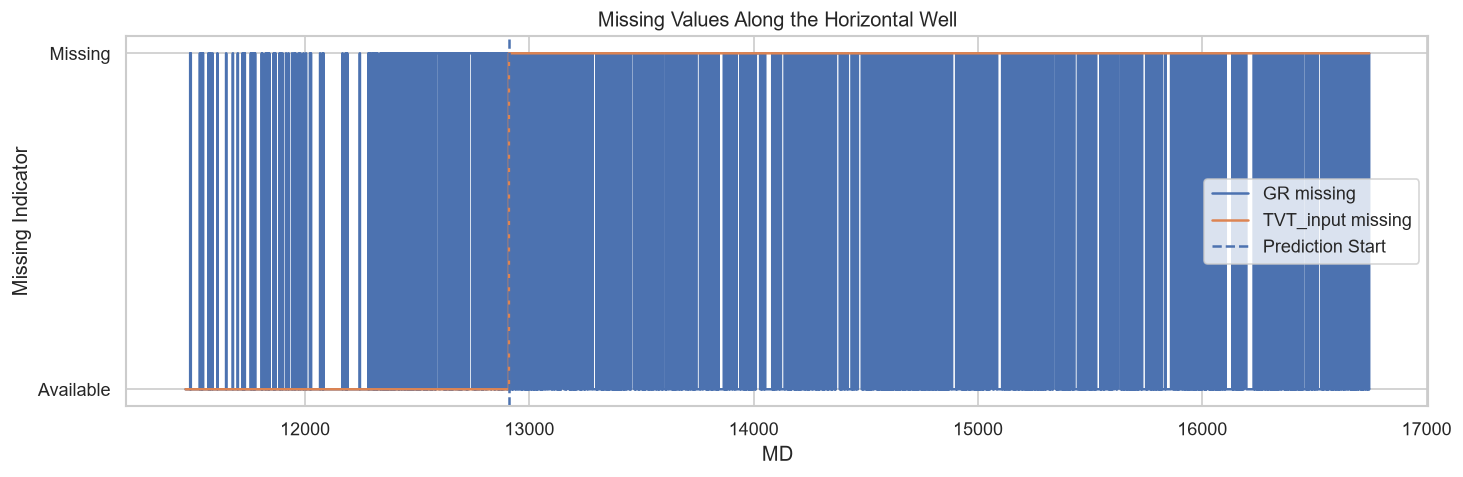

In [39]:
plt.figure(figsize=(14, 4))

plt.step(
    horizontal["MD"],
    horizontal["GR"].isna().astype(int),
    where="mid",
    label="GR missing"
)

plt.step(
    horizontal["MD"],
    horizontal["TVT_input"].isna().astype(int),
    where="mid",
    label="TVT_input missing"
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Missing Values Along the Horizontal Well")
plt.xlabel("MD")
plt.ylabel("Missing Indicator")
plt.yticks([0, 1], ["Available", "Missing"])
plt.legend()
plt.show()

**Interpretation.** Missingness along MD shows `TVT_input` becoming absent after
Prediction Start, while GR missingness is more irregular. The results indicate
two missingness regimes: intentional trailing `TVT_input` blanks versus ordinary
GR gaps. Conventional imputation is inappropriate for `TVT_input`. GR missingness
should be handled with care in feature engineering and evaluated under grouped
validation.


## Typewell analysis

### 10. Typewell numerical summary and spacing

In [40]:
display(typewell[["TVT", "GR"]].describe().T)

typewell_tvt_spacing = typewell["TVT"].diff().dropna()

print("TVT spacing summary:")
display(typewell_tvt_spacing.describe())

,count,mean,std,min,25%,50%,75%,max
TVT,"1,296.0000","11,547.7000",187.1336,"11,223.9500","11,385.8250","11,547.7000","11,709.5750","11,871.4500"
GR,"1,296.0000",83.2576,26.2513,28.6600,64.9400,87.0900,102.8025,158.1800


TVT spacing summary:


count   1,295.0000
mean        0.5000
std         0.0000
min         0.5000
25%         0.5000
50%         0.5000
75%         0.5000
max         0.5000
Name: TVT, dtype: float64

### 11. Typewell geology distribution

Geology
ANCC     348
NaN      299
ASTNL    146
EGFDL    121
BUDA      96
LBHL      74
EGFDU     70
ASTNU     56
LTHL      31
LTGT      28
MNSS      27
Name: count, dtype: int64

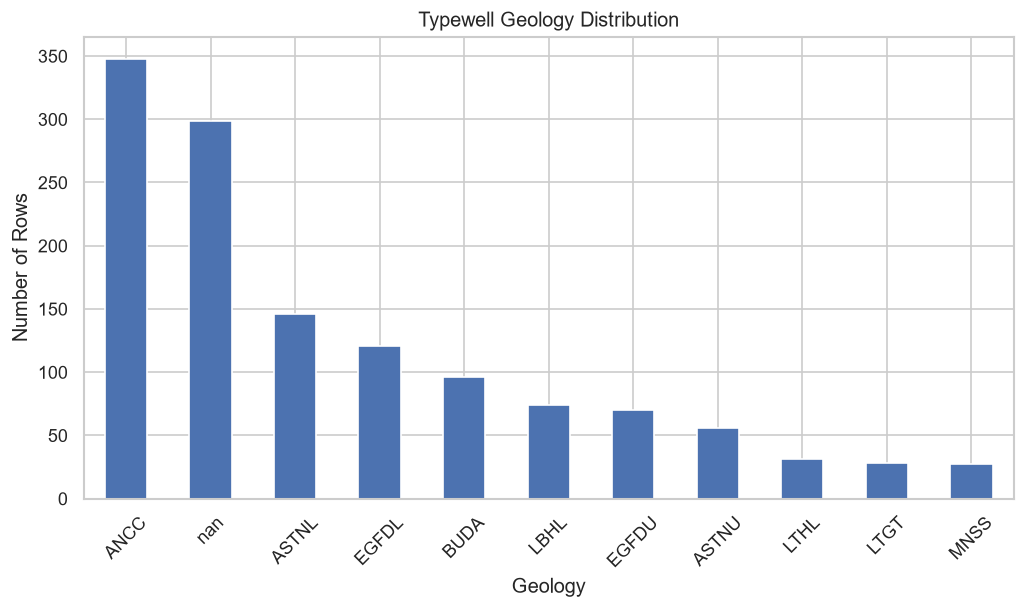

In [41]:
geology_counts = typewell["Geology"].value_counts(dropna=False)

display(geology_counts)

geology_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Typewell Geology Distribution")
plt.xlabel("Geology")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.show()

### 12. Summarize geology by TVT range

In [42]:
geology_summary = (
    typewell
    .groupby("Geology", dropna=False)
    .agg(
        Row_Count=("TVT", "size"),
        TVT_Min=("TVT", "min"),
        TVT_Max=("TVT", "max"),
        GR_Mean=("GR", "mean"),
        GR_Std=("GR", "std"),
        GR_Min=("GR", "min"),
        GR_Max=("GR", "max")
    )
    .sort_values("TVT_Min")
)

display(geology_summary)

,Row_Count,TVT_Min,TVT_Max,GR_Mean,GR_Std,GR_Min,GR_Max
Geology,,,,,,,
NaN,299,"11,223.9500","11,372.9500",109.2268,13.3469,88.6800,158.1800
ANCC,348,"11,373.4500","11,546.9500",86.0911,16.7921,48.2900,118.6200
ASTNU,56,"11,547.4500","11,574.9500",79.8721,14.3959,59.1300,121.8000
ASTNL,146,"11,575.4500","11,647.9500",50.7731,15.0367,30.1200,123.1800
EGFDU,70,"11,648.4500","11,682.9500",62.6260,7.4173,48.6400,80.7800
EGFDL,121,"11,683.4500","11,743.4500",92.1890,14.0074,60.8600,128.4200
LTHL,31,"11,743.9500","11,758.9500",94.7974,14.5658,66.9500,130.7100
LTGT,28,"11,759.4500","11,772.9500",79.3639,7.4910,61.3000,91.2200
LBHL,74,"11,773.4500","11,809.9500",85.6672,15.1129,57.8700,120.8500


### 13. Plot typewell GR against TVT

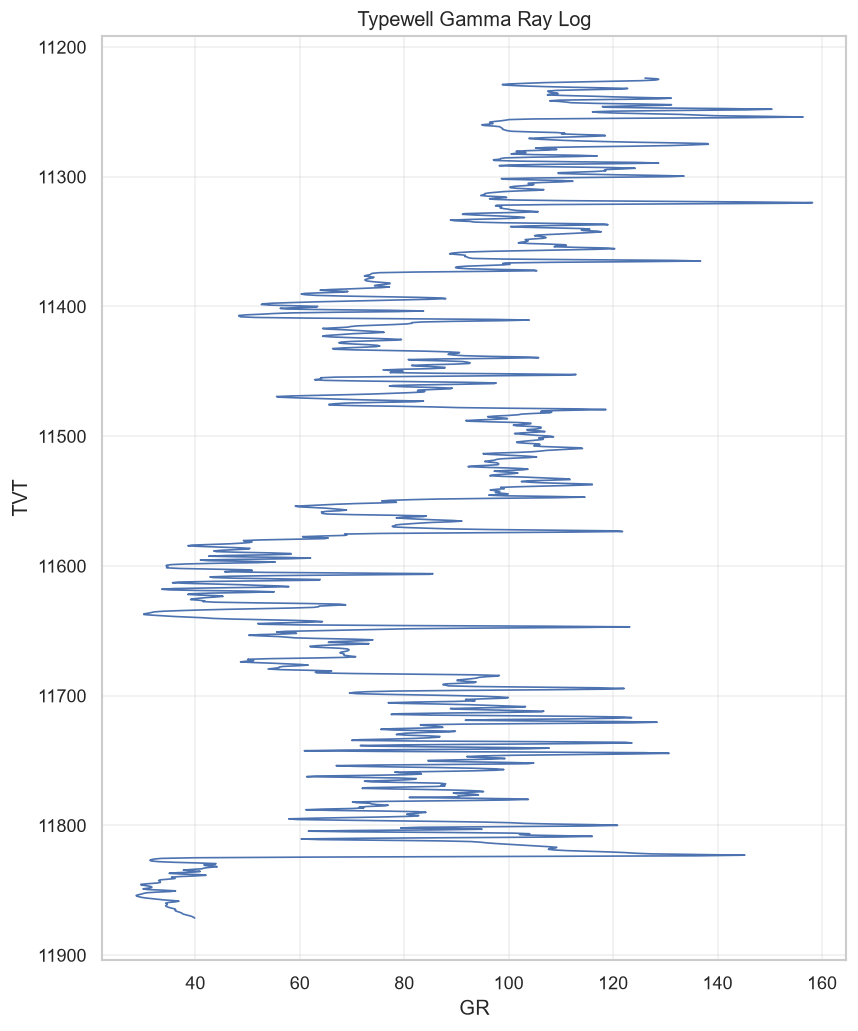

In [43]:
plt.figure(figsize=(8, 10))

plt.plot(typewell["GR"], typewell["TVT"], linewidth=1)

plt.gca().invert_yaxis()
plt.title("Typewell Gamma Ray Log")
plt.xlabel("GR")
plt.ylabel("TVT")
plt.grid(alpha=0.3)
plt.show()

## Horizontal-well analysis

### 14. MD sampling interval

In [44]:
horizontal_md_spacing = horizontal["MD"].diff().dropna()

display(horizontal_md_spacing.describe())

print("Most common MD intervals:")
display(horizontal_md_spacing.value_counts().head(10))

count   5,277.0000
mean        1.0000
std         0.0000
min         1.0000
25%         1.0000
50%         1.0000
75%         1.0000
max         1.0000
Name: MD, dtype: float64

Most common MD intervals:


MD
1.0000    5277
Name: count, dtype: int64

### 15. Plot horizontal-well trajectory

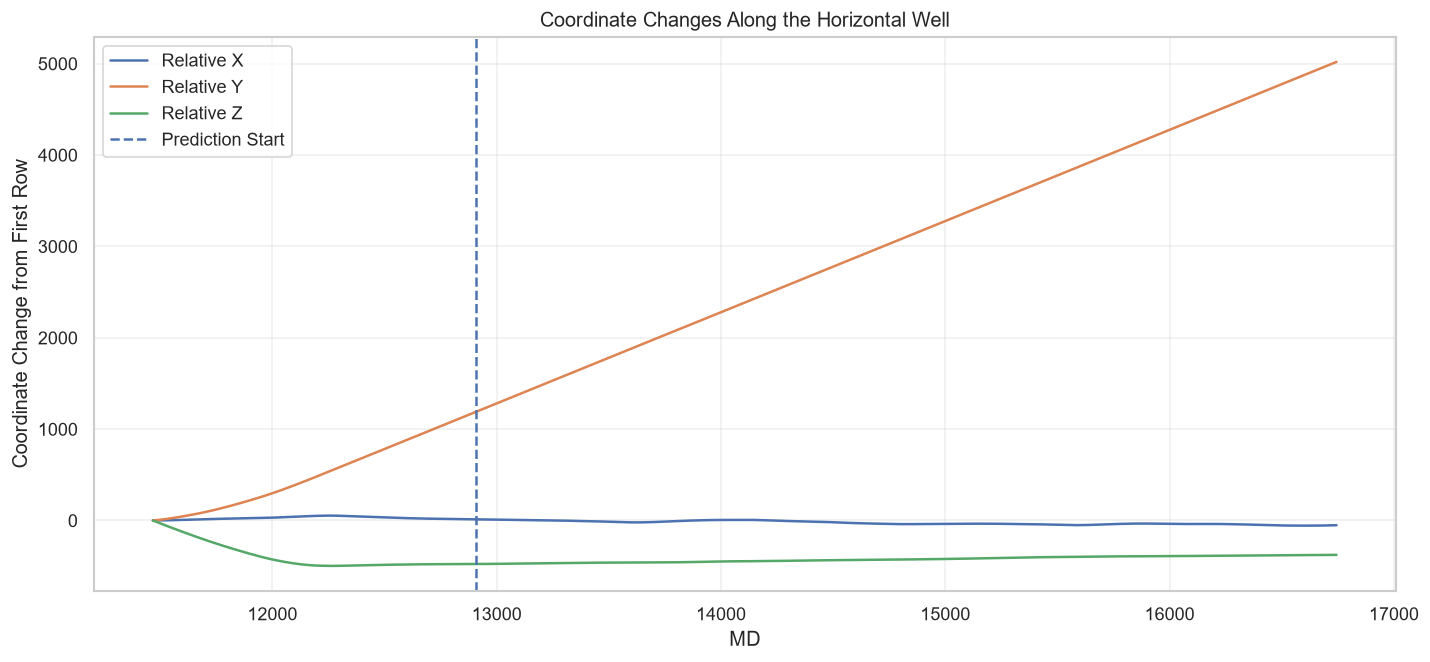

In [45]:
relative_coordinates = horizontal[["X", "Y", "Z"]].copy()

relative_coordinates["X"] -= relative_coordinates["X"].iloc[0]
relative_coordinates["Y"] -= relative_coordinates["Y"].iloc[0]
relative_coordinates["Z"] -= relative_coordinates["Z"].iloc[0]

plt.figure(figsize=(14, 6))

plt.plot(horizontal["MD"], relative_coordinates["X"], label="Relative X")
plt.plot(horizontal["MD"], relative_coordinates["Y"], label="Relative Y")
plt.plot(horizontal["MD"], relative_coordinates["Z"], label="Relative Z")

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Coordinate Changes Along the Horizontal Well")
plt.xlabel("MD")
plt.ylabel("Coordinate Change from First Row")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Target behaviour

### 16. Calculate TVT changes and slopes

In [46]:
horizontal_eda = horizontal.copy()

horizontal_eda["delta_MD"] = horizontal_eda["MD"].diff()
horizontal_eda["delta_TVT"] = horizontal_eda["TVT"].diff()

horizontal_eda["TVT_slope"] = (
    horizontal_eda["delta_TVT"]
    / horizontal_eda["delta_MD"]
)

horizontal_eda["Zone"] = np.where(
    known_tvt_mask,
    "Known Section",
    "Prediction Section"
)

display(
    horizontal_eda[
        ["MD", "TVT", "TVT_input", "delta_TVT", "TVT_slope", "Zone"]
    ].head()
)

,MD,TVT,TVT_input,delta_TVT,TVT_slope,Zone
0,"11,467.0000","11,236.0200","11,236.0200",NaN,NaN,Known Section
1,"11,468.0000","11,237.0500","11,237.0500",1.0300,1.0300,Known Section
2,"11,469.0000","11,238.0900","11,238.0900",1.0400,1.0400,Known Section
3,"11,470.0000","11,239.1200","11,239.1200",1.0300,1.0300,Known Section
4,"11,471.0000","11,240.1500","11,240.1500",1.0300,1.0300,Known Section


### 17. Count increasing, decreasing and flat TVT movements

Increasing            2040
Decreasing            1901
Approximately Flat    1336
dtype: int64

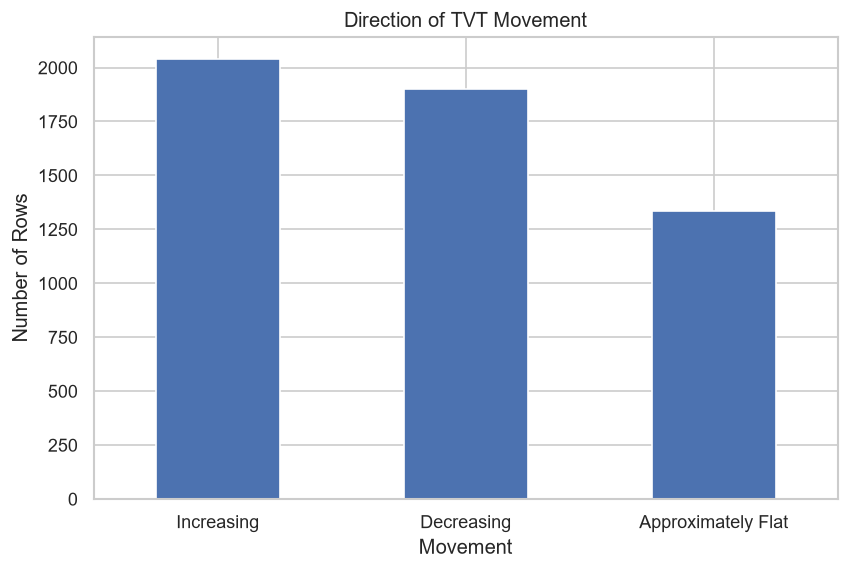

In [47]:
tolerance = 1e-6

direction_counts = pd.Series({
    "Increasing": (horizontal_eda["delta_TVT"] > tolerance).sum(),
    "Decreasing": (horizontal_eda["delta_TVT"] < -tolerance).sum(),
    "Approximately Flat": (
        horizontal_eda["delta_TVT"].abs() <= tolerance
    ).sum()
})

display(direction_counts)

direction_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Direction of TVT Movement")
plt.xlabel("Movement")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.show()

### 18. Compare known and prediction sections

In [48]:
zone_summary = (
    horizontal_eda
    .groupby("Zone")
    .agg(
        Rows=("MD", "size"),
        MD_Min=("MD", "min"),
        MD_Max=("MD", "max"),
        TVT_Min=("TVT", "min"),
        TVT_Max=("TVT", "max"),
        TVT_Mean=("TVT", "mean"),
        TVT_Slope_Mean=("TVT_slope", "mean"),
        TVT_Slope_Std=("TVT_slope", "std"),
        GR_Available=("GR", "count")
    )
)

zone_summary["GR_Missing"] = (
    zone_summary["Rows"] - zone_summary["GR_Available"]
)

zone_summary["GR_Missing_Percentage"] = (
    zone_summary["GR_Missing"]
    / zone_summary["Rows"]
    * 100
)

display(zone_summary)

,Rows,MD_Min,MD_Max,TVT_Min,TVT_Max,TVT_Mean,TVT_Slope_Mean,TVT_Slope_Std,GR_Available,GR_Missing,GR_Missing_Percentage
Zone,,,,,,,,,,,
Known Section,1442,"11,467.0000","12,908.0000","11,236.0200","11,756.1200","11,646.4179",0.3549,0.4217,1000,442,30.6519
Prediction Section,3836,"12,909.0000","16,744.0000","11,734.8300","11,750.0300","11,741.9244",-0.0026,0.0126,2020,1816,47.3410


### 19. Plot TVT change along MD

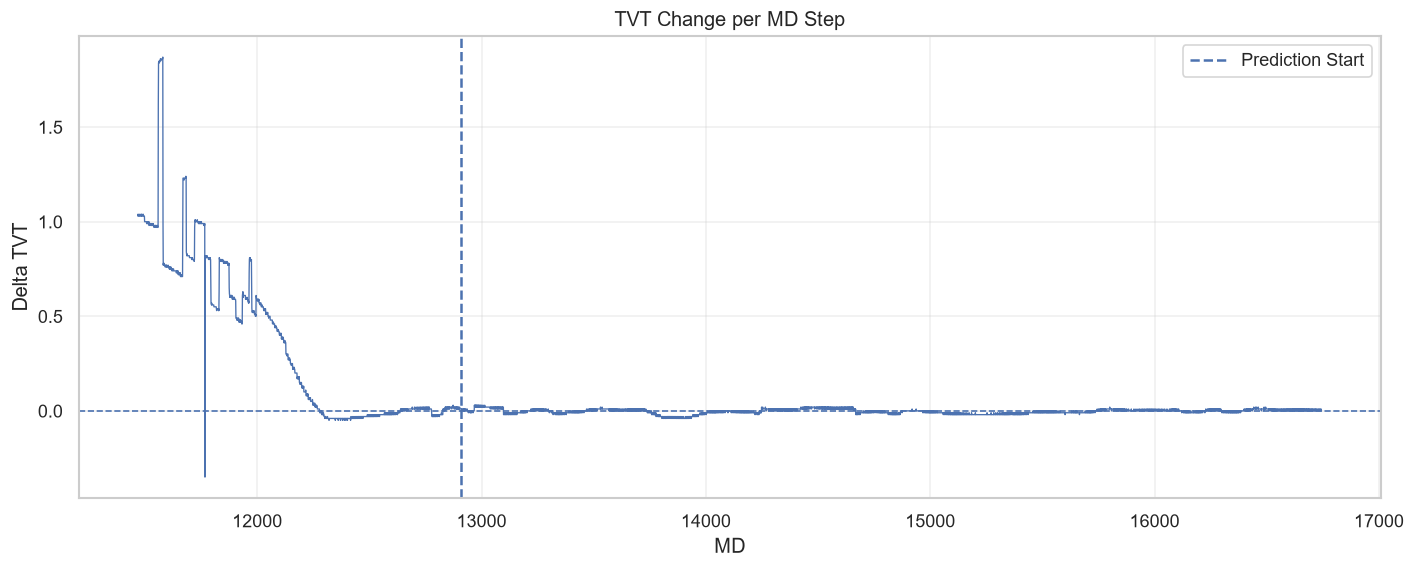

In [49]:
plt.figure(figsize=(14, 5))

plt.plot(
    horizontal_eda["MD"],
    horizontal_eda["delta_TVT"],
    linewidth=0.8
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("TVT Change per MD Step")
plt.xlabel("MD")
plt.ylabel("Delta TVT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## GR analysis

### 20. Horizontal GR distribution and availability

count   3,020.0000
mean       94.4370
std        18.6275
min        31.7658
25%        85.0683
50%        94.9365
75%       103.9609
max       217.3523
Name: GR, dtype: float64

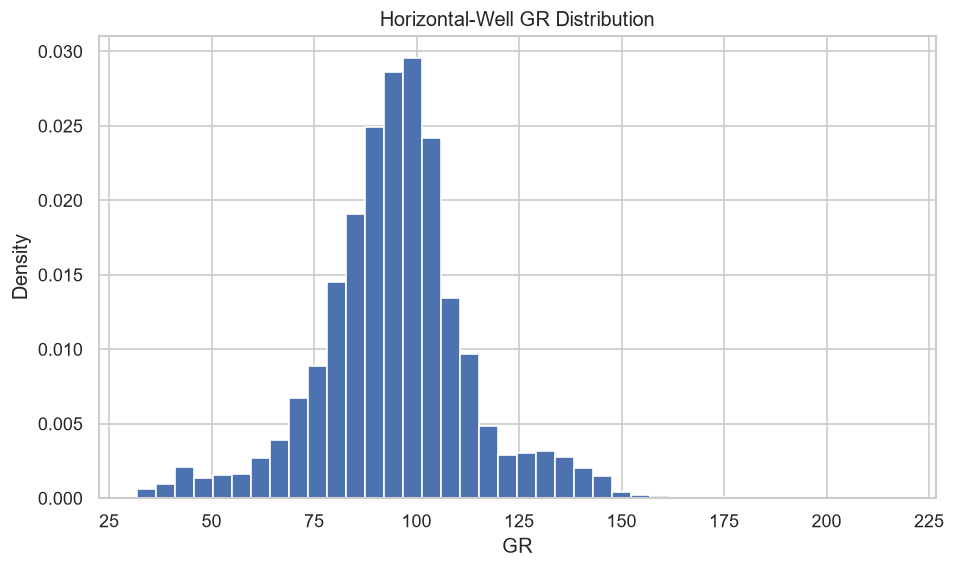

In [50]:
display(horizontal["GR"].describe())

plt.figure(figsize=(9, 5))

horizontal["GR"].dropna().plot(
    kind="hist",
    bins=40,
    density=True
)

plt.title("Horizontal-Well GR Distribution")
plt.xlabel("GR")
plt.ylabel("Density")
plt.show()

### 21. Plot GR along MD

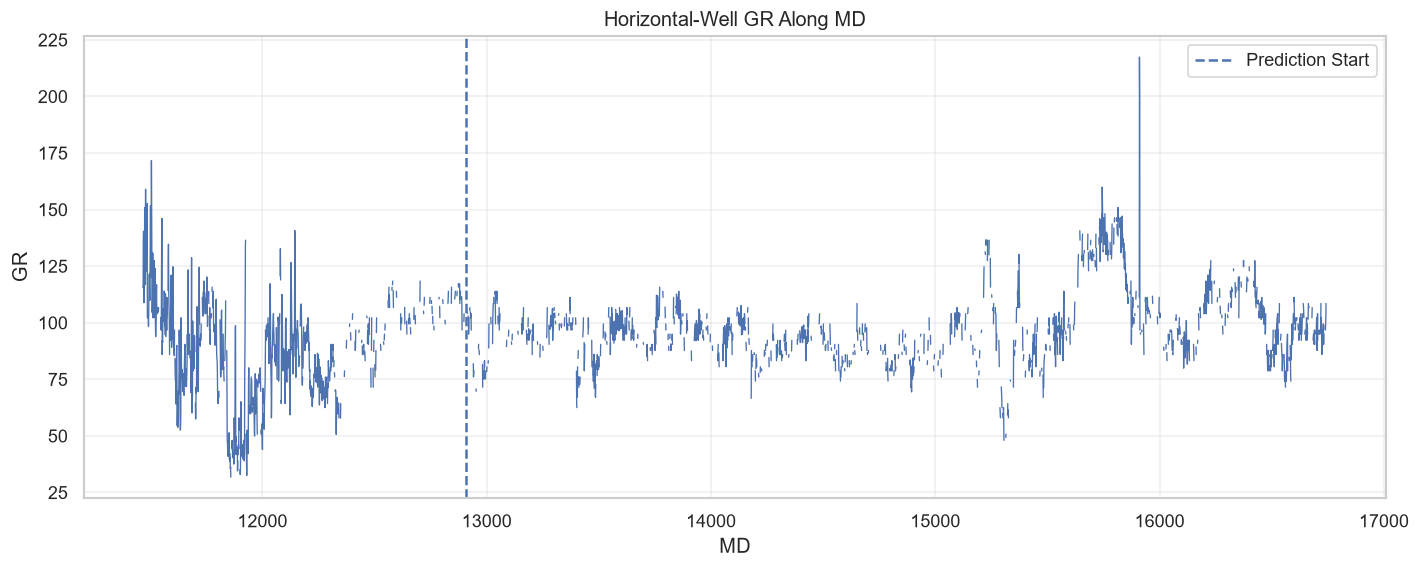

In [51]:
plt.figure(figsize=(14, 5))

plt.plot(
    horizontal["MD"],
    horizontal["GR"],
    linewidth=0.8
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Horizontal-Well GR Along MD")
plt.xlabel("MD")
plt.ylabel("GR")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paired-well comparison

### 22. Compare TVT ranges

In [52]:
typewell_tvt_min = typewell["TVT"].min()
typewell_tvt_max = typewell["TVT"].max()

horizontal_tvt_min = horizontal["TVT"].min()
horizontal_tvt_max = horizontal["TVT"].max()

overlap_min = max(typewell_tvt_min, horizontal_tvt_min)
overlap_max = min(typewell_tvt_max, horizontal_tvt_max)

has_overlap = overlap_max >= overlap_min

horizontal_inside_typewell = (
    horizontal_tvt_min >= typewell_tvt_min
    and horizontal_tvt_max <= typewell_tvt_max
)

print("Typewell TVT range:")
print(typewell_tvt_min, "to", typewell_tvt_max)

print("\nHorizontal TVT range:")
print(horizontal_tvt_min, "to", horizontal_tvt_max)

print("\nOverlap:")
print(overlap_min, "to", overlap_max)

print("\nHas overlap:", has_overlap)
print("Horizontal range is inside typewell range:", horizontal_inside_typewell)

Typewell TVT range:
11223.95 to 11871.45

Horizontal TVT range:
11236.02 to 11756.12

Overlap:
11236.02 to 11756.12

Has overlap: True
Horizontal range is inside typewell range: True


### 23. Compare GR distributions correctly

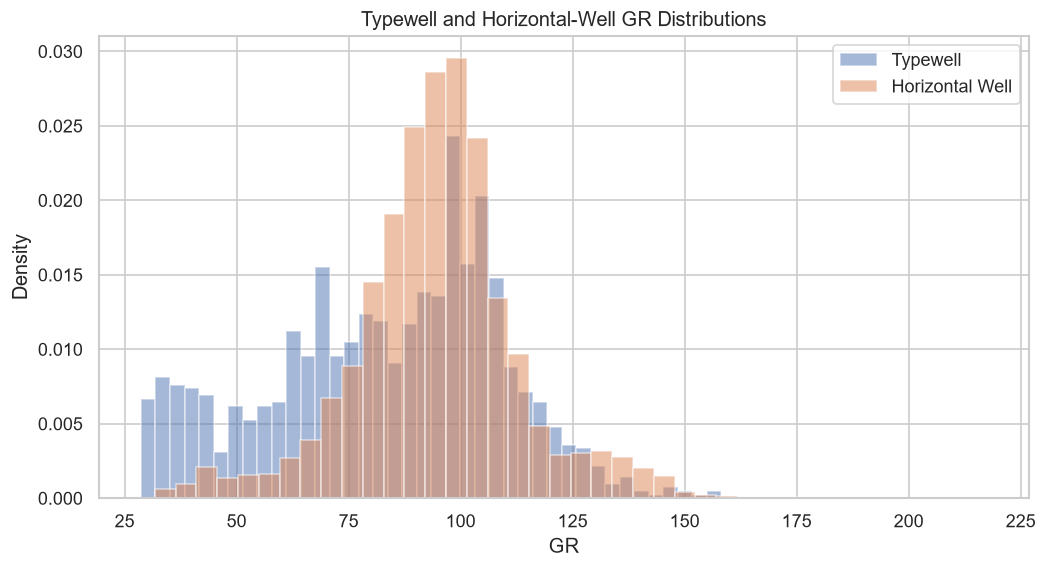

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    typewell["GR"].dropna(),
    bins=40,
    density=True,
    alpha=0.5,
    label="Typewell"
)

plt.hist(
    horizontal["GR"].dropna(),
    bins=40,
    density=True,
    alpha=0.5,
    label="Horizontal Well"
)

plt.title("Typewell and Horizontal-Well GR Distributions")
plt.xlabel("GR")
plt.ylabel("Density")
plt.legend()
plt.show()

### 24. Compare GR against TVT by zone

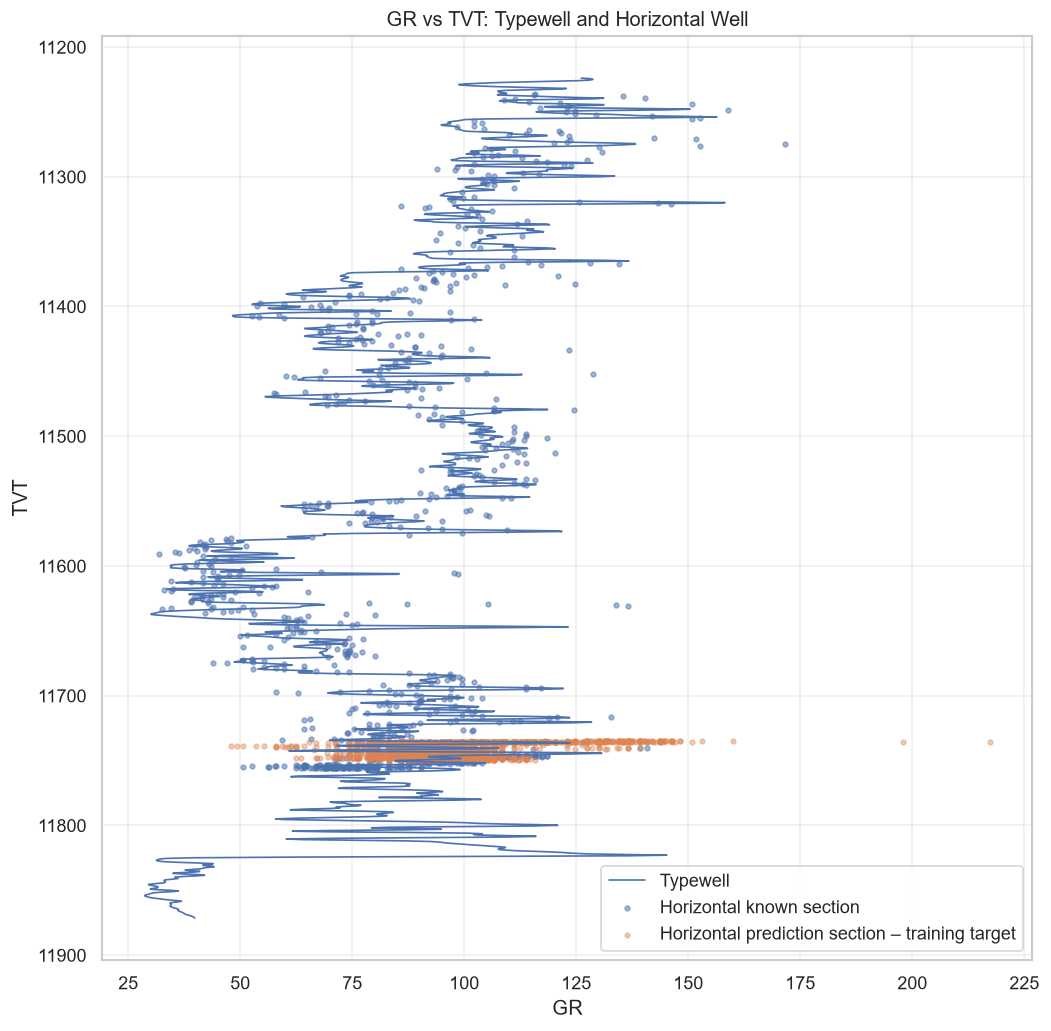

In [54]:
known_gr_mask = known_tvt_mask & horizontal["GR"].notna()
prediction_gr_mask = (~known_tvt_mask) & horizontal["GR"].notna()

plt.figure(figsize=(10, 10))

plt.plot(
    typewell["GR"],
    typewell["TVT"],
    linewidth=1,
    label="Typewell"
)

plt.scatter(
    horizontal.loc[known_gr_mask, "GR"],
    horizontal.loc[known_gr_mask, "TVT_input"],
    s=8,
    alpha=0.5,
    label="Horizontal known section"
)

plt.scatter(
    horizontal.loc[prediction_gr_mask, "GR"],
    horizontal.loc[prediction_gr_mask, "TVT"],
    s=8,
    alpha=0.4,
    label="Horizontal prediction section – training target"
)

plt.gca().invert_yaxis()
plt.title("GR vs TVT: Typewell and Horizontal Well")
plt.xlabel("GR")
plt.ylabel("TVT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Formation columns

### 25. Correctly identify column groups

`TVT` is the training target. `TVT_input` is a partial, known-region input and
the intentional prediction mask; it is not listed as a modelling target column.


In [55]:
trajectory_columns = ["MD", "X", "Y", "Z"]
formation_columns = [
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA",
]
log_columns = ["GR"]
target_columns = ["TVT"]
known_input_columns = ["TVT_input"]

print("Trajectory columns:", trajectory_columns)
print("Formation columns:", formation_columns)
print("Log columns:", log_columns)
print("Target columns:", target_columns)
print("Known-region input / mask columns:", known_input_columns)


Trajectory columns: ['MD', 'X', 'Y', 'Z']
Formation columns: ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
Log columns: ['GR']
Target columns: ['TVT']
Known-region input / mask columns: ['TVT_input']


In [56]:
available_formation_columns = [
    column
    for column in formation_columns
    if column in horizontal.columns
]

display(
    horizontal[available_formation_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
ANCC,"5,278.0000","-9,330.6218",35.2730,"-9,395.8100","-9,362.3075","-9,335.9750","-9,296.6650","-9,271.0000"
ASTNU,"5,278.0000","-9,504.6718",35.2730,"-9,569.8600","-9,536.3575","-9,510.0250","-9,470.7150","-9,445.0500"
ASTNL,"5,278.0000","-9,532.4518",35.2730,"-9,597.6400","-9,564.1375","-9,537.8050","-9,498.4950","-9,472.8300"
EGFDU,"5,278.0000","-9,605.8018",35.2730,"-9,670.9900","-9,637.4875","-9,611.1550","-9,571.8450","-9,546.1800"
EGFDL,"5,278.0000","-9,640.7718",35.2730,"-9,705.9600","-9,672.4575","-9,646.1250","-9,606.8150","-9,581.1500"
BUDA,"5,278.0000","-9,781.1618",35.2730,"-9,846.3500","-9,812.8475","-9,786.5150","-9,747.2050","-9,721.5400"


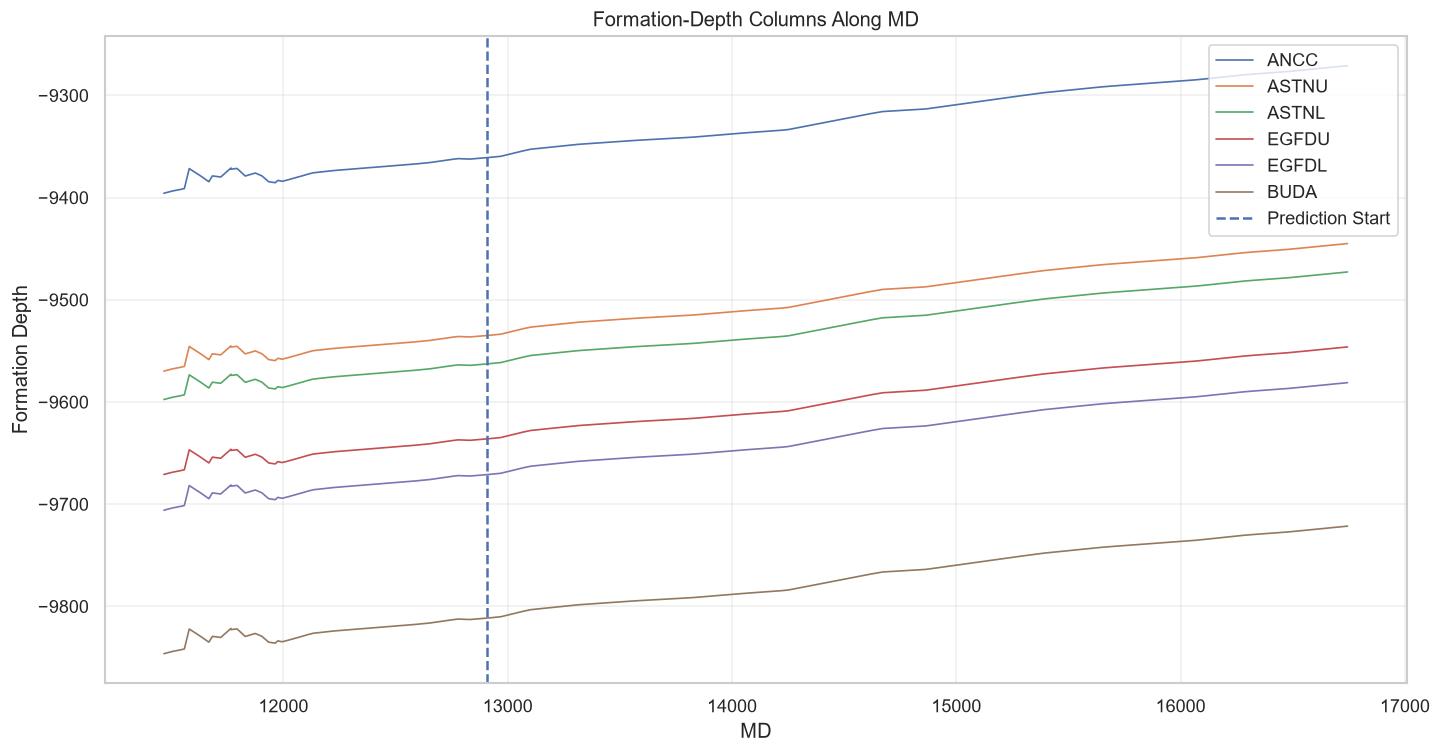

In [57]:
plt.figure(figsize=(14, 7))

for column in available_formation_columns:
    plt.plot(
        horizontal["MD"],
        horizontal[column],
        label=column,
        linewidth=1
    )

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Formation-Depth Columns Along MD")
plt.xlabel("MD")
plt.ylabel("Formation Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Correlation analysis

### 26. Feature correlation analysis

Pearson correlation summarises **linear** associations only. Correlation does
not imply causation and is not used alone to justify feature selection.
`TVT_input` is excluded from the principal heatmap because, on known rows, it
reproduces `TVT` by construction (correlation of 1.0 is expected there).
A Spearman heatmap is included as a supplementary rank-based comparison.


Used all 5,278 rows (seed=42).
Columns in principal heatmap: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
TVT_input excluded from principal heatmap: True


,MD,X,Y,Z,GR,TVT,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA
MD,1.0000,-0.9050,1.0000,-0.0580,0.3180,0.4480,0.9960,0.9960,0.9960,0.9960,0.9960,0.9960
X,-0.9050,1.0000,-0.9100,-0.1910,-0.3290,-0.1900,-0.9170,-0.9170,-0.9170,-0.9170,-0.9170,-0.9170
Y,1.0000,-0.9100,1.0000,-0.0350,0.3240,0.4280,0.9960,0.9960,0.9960,0.9960,0.9960,0.9960
Z,-0.0580,-0.1910,-0.0350,1.0000,0.1250,-0.9180,-0.0150,-0.0150,-0.0150,-0.0150,-0.0150,-0.0150
GR,0.3180,-0.3290,0.3240,0.1250,1.0000,0.0010,0.3200,0.3200,0.3200,0.3200,0.3200,0.3200
TVT,0.4480,-0.1900,0.4280,-0.9180,0.0010,1.0000,0.4110,0.4110,0.4110,0.4110,0.4110,0.4110
ANCC,0.9960,-0.9170,0.9960,-0.0150,0.3200,0.4110,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
ASTNU,0.9960,-0.9170,0.9960,-0.0150,0.3200,0.4110,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
ASTNL,0.9960,-0.9170,0.9960,-0.0150,0.3200,0.4110,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
EGFDU,0.9960,-0.9170,0.9960,-0.0150,0.3200,0.4110,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


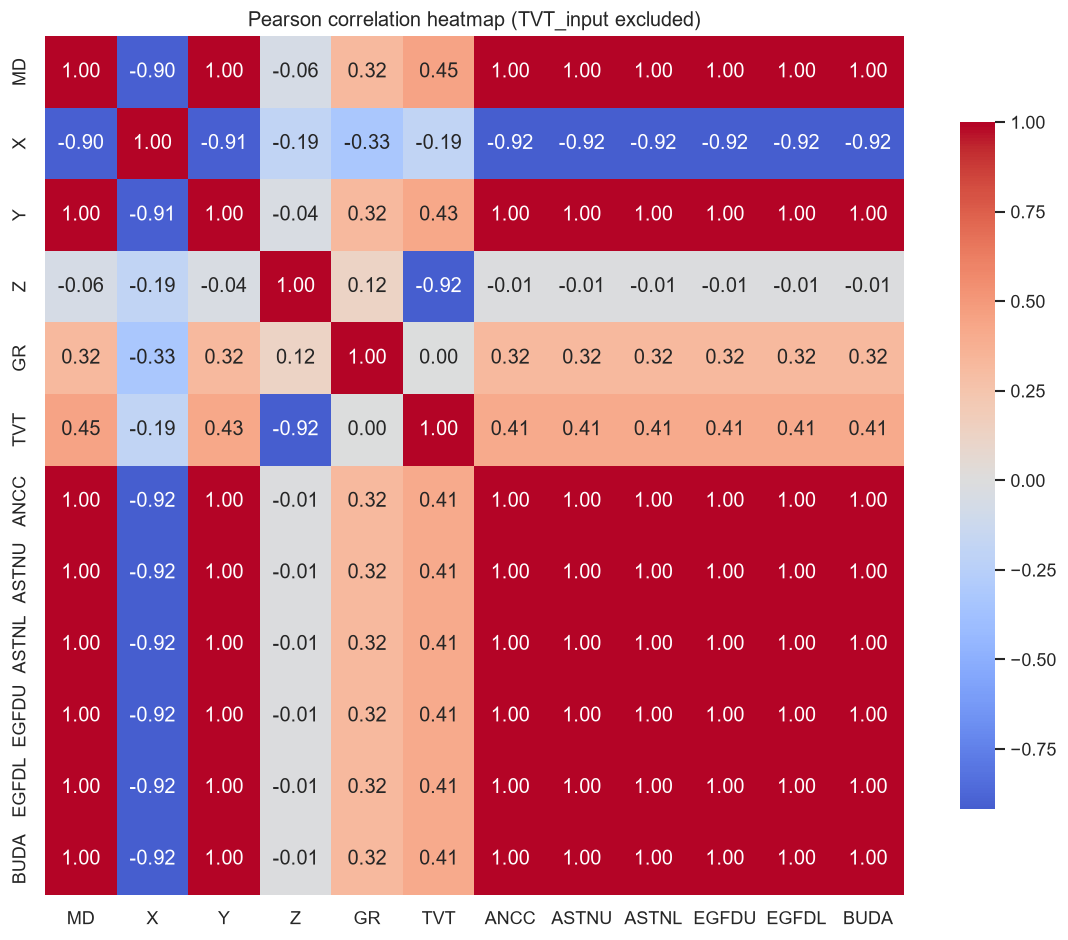

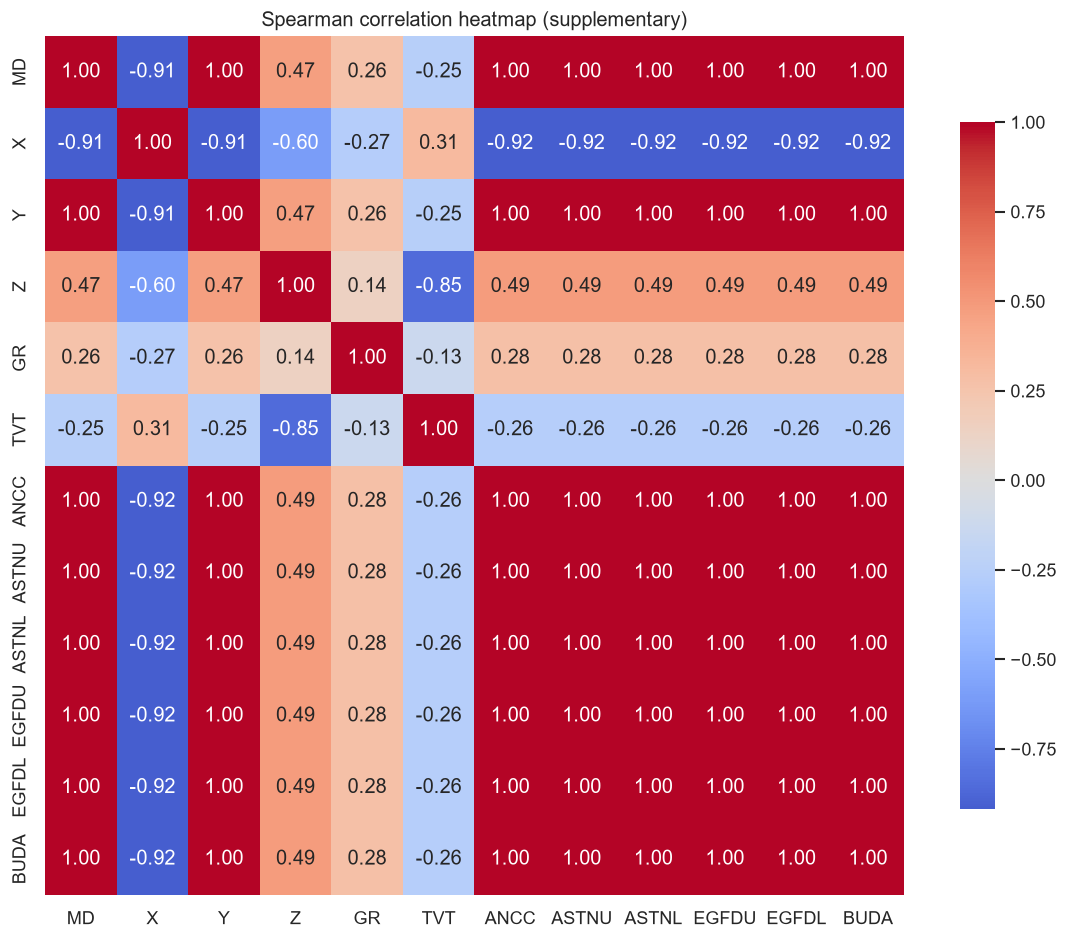

Known-region corr(TVT_input, TVT) = 1.0 (expected ~1.0 by construction)

Absolute Pearson |corr| with TVT:


,abs_pearson_with_TVT
Z,0.9180
MD,0.4480
Y,0.4280
EGFDU,0.4110
ANCC,0.4110
ASTNL,0.4110
EGFDL,0.4110
ASTNU,0.4110
BUDA,0.4110
X,0.1900


Strongest feature-feature absolute Pearson correlations:


,Feature_A,Feature_B,Abs_Pearson
4,ANCC,ASTNU,1.0000
5,ANCC,EGFDU,1.0000
6,ASTNU,EGFDL,1.0000
7,ASTNL,ASTNU,1.0000
9,BUDA,EGFDL,1.0000
11,ASTNL,BUDA,1.0000
13,ASTNU,EGFDU,1.0000
14,BUDA,EGFDU,1.0000
16,ANCC,BUDA,1.0000
18,ANCC,ASTNL,1.0000


In [58]:
correlation_candidate_columns = [
    "MD",
    "X",
    "Y",
    "Z",
    "GR",
    "TVT",
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA",
]

correlation_columns = [
    column
    for column in correlation_candidate_columns
    if column in horizontal_eda.columns
]

corr_data = horizontal_eda[correlation_columns].copy()
n_rows_available = len(corr_data)
max_corr_sample = 50_000
if n_rows_available > max_corr_sample:
    corr_sample = corr_data.sample(n=max_corr_sample, random_state=RANDOM_SEED)
    sample_note = f"Sampled {max_corr_sample:,} of {n_rows_available:,} rows (seed={RANDOM_SEED})."
else:
    corr_sample = corr_data
    sample_note = f"Used all {n_rows_available:,} rows (seed={RANDOM_SEED})."

pearson_corr = corr_sample.corr(method="pearson")
spearman_corr = corr_sample.corr(method="spearman")

print(sample_note)
print("Columns in principal heatmap:", correlation_columns)
print("TVT_input excluded from principal heatmap: True")

display(pearson_corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Pearson correlation heatmap (TVT_input excluded)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pearson_correlation_heatmap.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Spearman correlation heatmap (supplementary)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "spearman_correlation_heatmap.png", bbox_inches="tight")
plt.show()

pearson_corr.to_csv(TABLES_DIR / "pearson_correlation_matrix.csv")
spearman_corr.to_csv(TABLES_DIR / "spearman_correlation_matrix.csv")

# Optional sanity check: known-region TVT_input vs TVT identity
if "TVT_input" in horizontal_eda.columns:
    known_only = horizontal_eda.loc[known_tvt_mask, ["TVT_input", "TVT"]].dropna()
    if len(known_only) >= 2:
        identity_corr = known_only["TVT_input"].corr(known_only["TVT"])
        print(
            "Known-region corr(TVT_input, TVT) =",
            round(float(identity_corr), 6),
            "(expected ~1.0 by construction)",
        )

# Highlight strong feature-feature correlations and weak linear TVT links
tvt_links = (
    pearson_corr["TVT"]
    .drop(labels=["TVT"], errors="ignore")
    .abs()
    .sort_values(ascending=False)
)
print("\nAbsolute Pearson |corr| with TVT:")
display(tvt_links.round(3).to_frame("abs_pearson_with_TVT"))

feature_feature = pearson_corr.copy()
ff_values = feature_feature.to_numpy(copy=True)
np.fill_diagonal(ff_values, np.nan)
feature_feature = pd.DataFrame(ff_values, index=feature_feature.index, columns=feature_feature.columns)
strong_pairs = (
    feature_feature
    .abs()
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)
strong_pairs.columns = ["Feature_A", "Feature_B", "Abs_Pearson"]
strong_pairs = strong_pairs.loc[
    strong_pairs["Feature_A"] < strong_pairs["Feature_B"]
].head(10)
print("Strongest feature-feature absolute Pearson correlations:")
display(strong_pairs)


**Interpretation.** The heatmaps show linear (Pearson) and rank-based (Spearman)
associations among trajectory, formation, GR and TVT columns for this well.
The most important numerical pattern is typically a strong association between
vertical coordinate / formation markers and TVT, while GR may show a weaker
linear link. This matters because strong feature–feature correlations can
indicate redundancy, and weak linear TVT links do not rule out nonlinear or
sequence-dependent usefulness. The limitation is that this is one well and
Pearson captures only linear relationships. The implication is that feature
selection and engineering should be validated with grouped, well-level methods
rather than correlation alone. `TVT_input` remains excluded from the principal
heatmap because its known-region agreement with `TVT` is definitional.


### 27. Final sample summary


In [59]:
sample_summary = pd.Series({
    "Well ID": sample_id,
    "Typewell Rows": len(typewell),
    "Horizontal Rows": len(horizontal),
    "Known TVT Rows": known_rows,
    "Prediction Rows": prediction_rows,
    "Prediction Percentage": round(100 * prediction_rows / len(horizontal), 2),
    "Prediction Start MD": prediction_start_md,
    "Last Known TVT_input": last_known_tvt,
    "Prediction Horizon MD": round(prediction_horizon_md, 2),
    "Clean Trailing TVT_input Block": clean_prediction_boundary,
    "Unexpected Internal Gaps": unexpected_internal_gaps,
    "TVT_input Matches TVT": tvt_input_matches_target,
    "Typewell Covers Horizontal TVT": horizontal_inside_typewell,
    "Selection Note": "Lexicographic worked example; not statistically representative",
})

display(sample_summary.to_frame("Value"))
sample_summary.to_frame("Value").to_csv(TABLES_DIR / "illustrative_well_summary.csv")


,Value
Well ID,000d7d20
Typewell Rows,1296
Horizontal Rows,5278
Known TVT Rows,1442
Prediction Rows,3836
Prediction Percentage,72.6800
Prediction Start MD,"12,909.0000"
Last Known TVT_input,"11,747.3700"
Prediction Horizon MD,"3,835.0000"
Clean Trailing TVT_input Block,True


### 28. EDA Conclusions for the Selected Well Pair

- The typewell and horizontal-well files form a valid paired dataset with
  suffix-safe well IDs.
- The typewell provides a geological reference curve (`TVT`, `GR`, formation
  labels). The horizontal well provides trajectory, GR, known `TVT_input`, and
  the training target `TVT`.
- `TVT_input` is available before Prediction Start and becomes missing
  continuously afterward on this well. That missingness is intentional and must
  not be treated with ordinary mean/median imputation.
- Exact agreement of `TVT_input` with `TVT` on known rows is expected and is not
  presented as a predictive discovery.
- TVT can increase, decrease, or remain locally flat, so MD alone is an
  unreliable predictor for this pair.
- GR is informative where observed but is substantially missing; models should
  not rely on GR alone.
- Linear correlations among trajectory and formation markers suggest possible
  redundancy; correlation alone does not justify feature selection.
- Full `TVT` is available for training evaluation only and must not enter the
  model as an input feature.
- These findings come from one lexicographic worked example. Dataset-wide
  patterns, criteria-based example wells, train–test comparison, and outlier
  screening are deferred to Notebook 03.


### 29. Academic notes on leakage and validation for this pair

1. Using complete `TVT` as a feature would leak the prediction target.
2. Treating `TVT_input` missingness as ordinary missing data would distort the
   prediction mask.
3. Rows from the same well are dependent; random row-level train/validation
   splits can leak well-specific structure into both folds.
4. Correlation evidence from a single well is provisional and should be examined
   through grouped, well-level validation across the full training corpus.
